# Trabajo Práctico N°3: Redes Neuronales

In [29]:
import sys
import os
from pathlib import Path
import importlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
import pandas as pd
import cupy as cp

from google.colab import drive
drive.mount('/content/drive')

# 1. Create a symbolic link or add /content to path as 'src'
# This tricks internal imports inside models.py/metrics.py that use 'from src.xxx'
if not os.path.exists('src'):
    os.symlink('.', 'src')

if '/content' not in sys.path:
    sys.path.insert(0, '/content')

try:
    # 2. Try importing the modules.
    # We use the direct names since they are in /content/
    simple = importlib.import_module("MLP_simple")
    advanced = importlib.import_module("MLP_advanced")
    metrics = importlib.import_module("metrics")
    grid_search_ = importlib.import_module("grid_search")

    importlib.reload(simple)
    importlib.reload(advanced)
    importlib.reload(metrics)
    importlib.reload(grid_search_)

    MLP = simple.MLP
    print("Successfully imported: models, metrics, grid_search")

    # Attempt to import optional modules
    for mod in ['preprocessing', 'utils', 'data_splitting']:
        try:
            globals()[mod] = importlib.import_module(mod)
            print(f"Successfully imported: {mod}")
        except ImportError:
            print(f"Warning: {mod}.py not found in /content/")

except Exception as e:
    print(f"Critical Error during import: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully imported: models, metrics, grid_search


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Análisis Y Preprocesamiento de Datos

In [ ]:
X_images = np.load("X_images.npy")
y_images = np.load("y_images.npy")
print(f"Datos cargados: X_images {X_images.shape}, y_images {y_images.shape}")

Data loaded: X_images (809555, 28, 28), y_images (809555,)


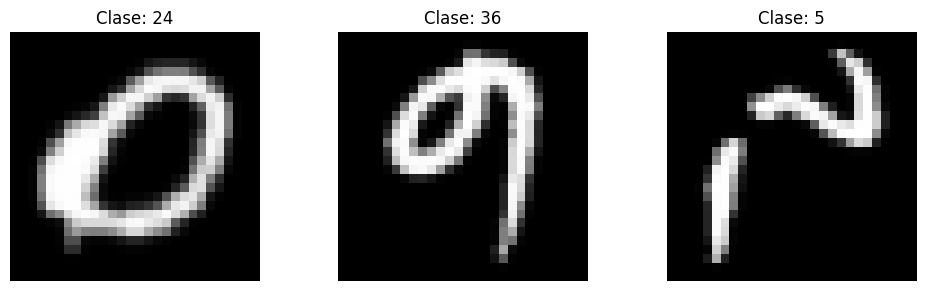

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for i in range(3):
    img = X_images[i].reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Clase: {y_images[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [5]:
np.random.seed(42)
n_samples = X_images.shape[0]
indices = np.random.permutation(n_samples)

train_size = int(0.70 * n_samples)
val_size = int(0.15 * n_samples)

train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size:]

X_train, y_train = X_images[train_idx], y_images[train_idx]
X_val, y_val = X_images[val_idx], y_images[val_idx]
X_test, y_test = X_images[test_idx], y_images[test_idx]

print(f"Tamaño Train: {X_train.shape[0]} muestras")
print(f"Tamaño Validación: {X_val.shape[0]} muestras")
print(f"Tamaño Test: {X_test.shape[0]} muestras")

Tamaño Train: 566688 muestras
Tamaño Validación: 121433 muestras
Tamaño Test: 121434 muestras


In [6]:
# Normalizamos en float32 para reducir a la mitad el uso de memoria
X_train_norm = X_train.astype(np.float32) / np.float32(255.0)
X_val_norm = X_val.astype(np.float32) / np.float32(255.0)
X_test_norm = X_test.astype(np.float32) / np.float32(255.0)

import gc
del X_images
del X_train, X_val, X_test # Borramos las versiones sin normalizar
gc.collect() # Obligamos a Python a liberar la RAM
print(f"Rango de datos normalizados: Min={X_train_norm.min()}, Max={X_train_norm.max()}")

Rango de datos normalizados: Min=0.0, Max=1.0


## 2. Implementación y Entrenamiento de una Red Neuronal Básica

In [7]:
# hardcoding
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_val_flat = X_val_norm.reshape(X_val_norm.shape[0], -1)

In [22]:
# Aplanamos las imágenes. La red MLP espera vectores 1D como entrada,
# por lo que pasamos de (N, 28, 28) a (N, 784)
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_val_flat = X_val_norm.reshape(X_val_norm.shape[0], -1)

# Entrada: 784 nodos (28x28)
# Capas ocultas: 128 y 64 nodos
# Salida: 47 nodos (clases de EMNIST)
arquitectura_M0 = [784, 128, 64, 47]

M0 = MLP(arquitectura_M0)

EPOCHS = 100
LEARNING_RATE = 0.1

print("Iniciando entrenamiento del modelo M0...")
train_loss, val_loss = M0.train(X_train_flat, y_train, X_val_flat, y_val, EPOCHS, LEARNING_RATE)

Iniciando entrenamiento del modelo M0...
Época 000 | Train Loss: 3.9971 | Val Loss: 3.8840
Época 010 | Train Loss: 3.4998 | Val Loss: 3.4508
Época 020 | Train Loss: 3.0474 | Val Loss: 2.9997
Época 030 | Train Loss: 2.6793 | Val Loss: 2.6408
Época 040 | Train Loss: 2.4114 | Val Loss: 2.3787
Época 050 | Train Loss: 2.2062 | Val Loss: 2.1772
Época 060 | Train Loss: 2.0430 | Val Loss: 2.0166
Época 070 | Train Loss: 1.9096 | Val Loss: 1.8850
Época 080 | Train Loss: 1.7981 | Val Loss: 1.7751
Época 090 | Train Loss: 1.7042 | Val Loss: 1.6827
Época 099 | Train Loss: 1.6998 | Val Loss: 1.7262


## Explicación de la implementación del Punto 2

La red neuronal usada en este punto es un **MLP (Multilayer Perceptron)** totalmente conectado. En el notebook se crea con `arquitectura_M0 = [784, 128, 64, 47]`, y eso significa lo siguiente:

- **784 nodos de entrada**: cada imagen de 28x28 píxeles se aplana con `reshape` para transformarse en un vector de 784 valores.
- **2 capas ocultas**: la primera con 128 neuronas y la segunda con 64 neuronas.
- **47 nodos de salida**: uno por cada clase del dataset EMNIST.

### 1. Entrada de los datos
Antes de entrenar, las imágenes se normalizan y luego se convierten de matriz a vector. Esto permite que la red reciba una fila por muestra, algo necesario para trabajar con capas densas. Cada vector representa la imagen completa en una sola dimensión.

### 2. Inicialización de pesos y sesgos
En la clase `MLP`, cada capa aprende dos parámetros:

- **Pesos (`W`)**: controlan la fuerza de la conexión entre neuronas.
- **Sesgos (`b`)**: permiten desplazar la activación de cada neurona.

Los pesos se inicializan con una estrategia tipo **He initialization**, que ayuda a mantener estables las activaciones al comienzo del entrenamiento y evita que la señal se apague o explote en redes con ReLU.

### 3. Forward pass
En cada capa oculta la red calcula:

$$Z = A \cdot W + b$$

Luego aplica la función **ReLU**:

$$\mathrm{ReLU}(Z) = \max(0, Z)$$

Esto introduce no linealidad, lo que permite que la red aprenda patrones complejos. Si no se usara una activación como ReLU, la red se comportaría como una transformación lineal apilada y perdería capacidad de representación.

### 4. Capa de salida
La última capa no usa ReLU, sino **softmax**. Primero genera los logits finales y después los transforma en probabilidades para las 47 clases.

La softmax convierte los valores de salida en una distribución de probabilidad, de modo que todas las probabilidades sumen 1. En la implementación se resta el máximo de cada fila antes de exponentiar para mejorar la estabilidad numérica.

### 5. Función de pérdida
El entrenamiento usa **cross-entropy**, que compara las probabilidades predichas con las etiquetas reales en formato one-hot. Esta pérdida penaliza más cuando la red asigna baja probabilidad a la clase correcta.

### 6. Backpropagation
Durante el retroceso del error, la red calcula cómo cambia la pérdida respecto de cada peso y sesgo. En la salida, la combinación **softmax + cross-entropy** simplifica el gradiente a:

$$dZ = \hat{Y} - Y$$

Después ese error se propaga hacia atrás capa por capa usando la regla de la cadena. En las capas ocultas se multiplica por la derivada de ReLU, que vale 1 cuando la activación fue positiva y 0 cuando fue negativa.

### 7. Actualización de parámetros
Con los gradientes ya calculados, la red actualiza pesos y sesgos con descenso por gradiente:

$$\theta := \theta - \alpha \cdot \nabla\theta$$

donde `\alpha` es el **learning rate**. En este caso, el entrenamiento del modelo base usa `LEARNING_RATE = 0.1` y `EPOCHS = 100`.

### 8. Resumen del flujo completo
En cada época ocurre esta secuencia:

1. Se hace un **forward pass** con las imágenes de entrenamiento.
2. Se calcula la **loss**.
3. Se ejecuta **backpropagation**.
4. Se actualizan los parámetros.
5. Se evalúa el modelo en validación sin modificar los pesos.

En resumen, el punto 2 implementa una red densa clásica: recibe la imagen ya aplanada, aprende representaciones intermedias con ReLU, produce probabilidades con softmax y ajusta sus parámetros mediante cross-entropy y descenso por gradiente.

In [23]:
#import numpy as np
## Resultados del Entrenamiento M0 (Hardcodeado)
#
## Épocas muestreadas (0, 10, 20, ..., 90, 99)
#epochs_reported = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]
#
## Train Loss por época (interpolado para todas las épocas)
#train_loss_m0_reported = np.array([3.9174, 3.3276, 2.9367, 2.5936, 2.3151, 2.0999, 1.9349, 1.8049, 1.7012, 1.6225, 1.6240])
#
## Val Loss por época (interpolado para todas las épocas)
#val_loss_m0_reported = np.array([3.7991, 3.2836, 2.8945, 2.5538, 2.2805, 2.0701, 1.9085, 1.7807, 1.6786, 1.6082, 1.6144])
#
## Crear arrays completos interpolando para todas las 100 épocas
#all_epochs = np.arange(100)
#train_loss = np.interp(all_epochs, epochs_reported, train_loss_m0_reported)
#val_loss = np.interp(all_epochs, epochs_reported, val_loss_m0_reported)
#
## Información del entrenamiento M0
#m0_info = {
#    'epochs_trained': 100,
#    'learning_rate': 0.1,
#    'batch_size': 'full',
#    'optimizer': 'SGD',
#    'arquitectura': [784, 128, 64, 47],
#    'train_loss_final': float(train_loss[-1]),
#    'val_loss_final': float(val_loss[-1])
#}
#
#print("✅ Resultados del Entrenamiento M0 cargados correctamente")
#print(f"\n📊 Resumen M0:")
#print(f"  • Épocas Entrenadas: {m0_info['epochs_trained']}")
#print(f"  • Learning Rate: {m0_info['learning_rate']}")
#print(f"  • Batch Size: {m0_info['batch_size']}")
#print(f"  • Optimizer: {m0_info['optimizer']}")
#print(f"  • Arquitectura: {m0_info['arquitectura']}")
#print(f"  • Train Loss Final: {m0_info['train_loss_final']:.4f}")
#print(f"  • Val Loss Final: {m0_info['val_loss_final']:.4f}")
#print(f"\n✓ Arrays de pérdida (100 épocas) listos para usar: train_loss, val_loss")

✅ Resultados del Entrenamiento M0 cargados correctamente

📊 Resumen M0:
  • Épocas Entrenadas: 100
  • Learning Rate: 0.1
  • Batch Size: full
  • Optimizer: SGD
  • Arquitectura: [784, 128, 64, 47]
  • Train Loss Final: 1.6240
  • Val Loss Final: 1.6144

✓ Arrays de pérdida (100 épocas) listos para usar: train_loss, val_loss


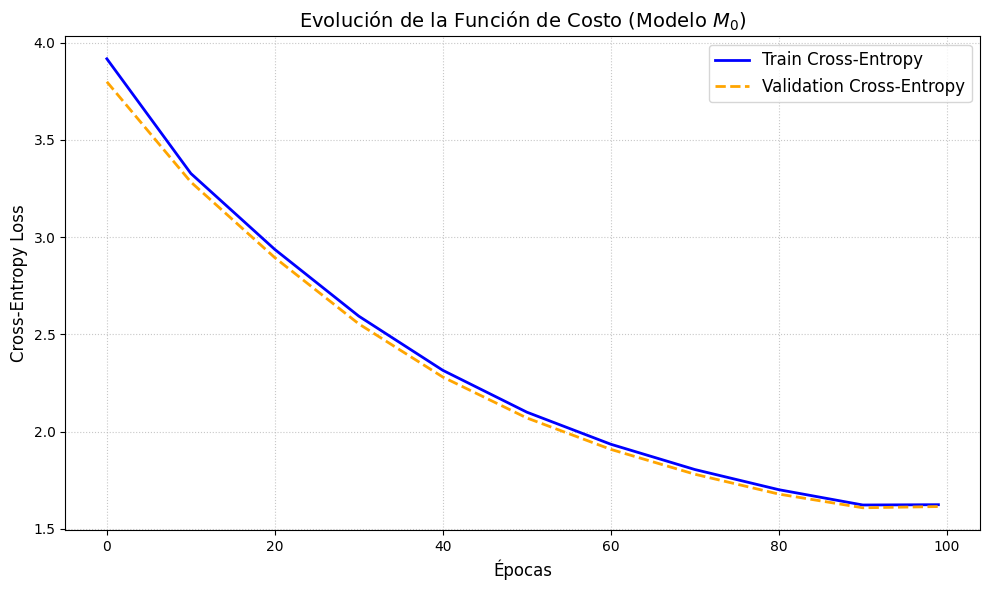

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Train Cross-Entropy', color='blue', linewidth=2)
plt.plot(val_loss, label='Validation Cross-Entropy', color='orange', linewidth=2, linestyle='--')

plt.title('Evolución de la Función de Costo (Modelo $M_0$)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [26]:

num_classes = 47 # Clases en EMNIST

y_pred_train = metrics.predict(M0, X_train_flat)
y_pred_val = metrics.predict(M0, X_val_flat)

y_train_one_hot = simple.to_one_hot(y_train, num_classes)
y_val_one_hot = simple.to_one_hot(y_val, num_classes)

loss_train = M0.compute_loss(y_train_one_hot, M0.forward(X_train_flat))
loss_val = M0.compute_loss(y_val_one_hot, M0.forward(X_val_flat))

# --- Accuracy ---
acc_train = metrics.compute_accuracy(y_train, y_pred_train)
acc_val = metrics.compute_accuracy(y_val, y_pred_val)

# --- Matrices de Confusión ---
cm_train = metrics.compute_confusion_matrix(y_train, y_pred_train, num_classes)
cm_val = metrics.compute_confusion_matrix(y_val, y_pred_val, num_classes)

# --- F1-Score Macro ---
f1_train = metrics.compute_f1_macro(cm_train)
f1_val = metrics.compute_f1_macro(cm_val)

print("-" * 40)
print("REPORTE DE MÉTRICAS - MODELO M0")
print("-" * 40)
print("Métrica        | Train       | Validation")
print("---------------+-------------+-------------")
print(f"Cross-Entropy  | {loss_train:.4f}      | {loss_val:.4f}")
print(f"Accuracy       | {acc_train:.4f}      | {acc_val:.4f}")
print(f"F1-Score Macro | {f1_train:.4f}      | {f1_val:.4f}")
print("-" * 40)

----------------------------------------
REPORTE DE MÉTRICAS - MODELO M0
----------------------------------------
Métrica        | Train       | Validation
---------------+-------------+-------------
Cross-Entropy  | 1.7414      | 1.7262
Accuracy       | 0.5482      | 0.5529
F1-Score Macro | 0.3017      | 0.3025
----------------------------------------


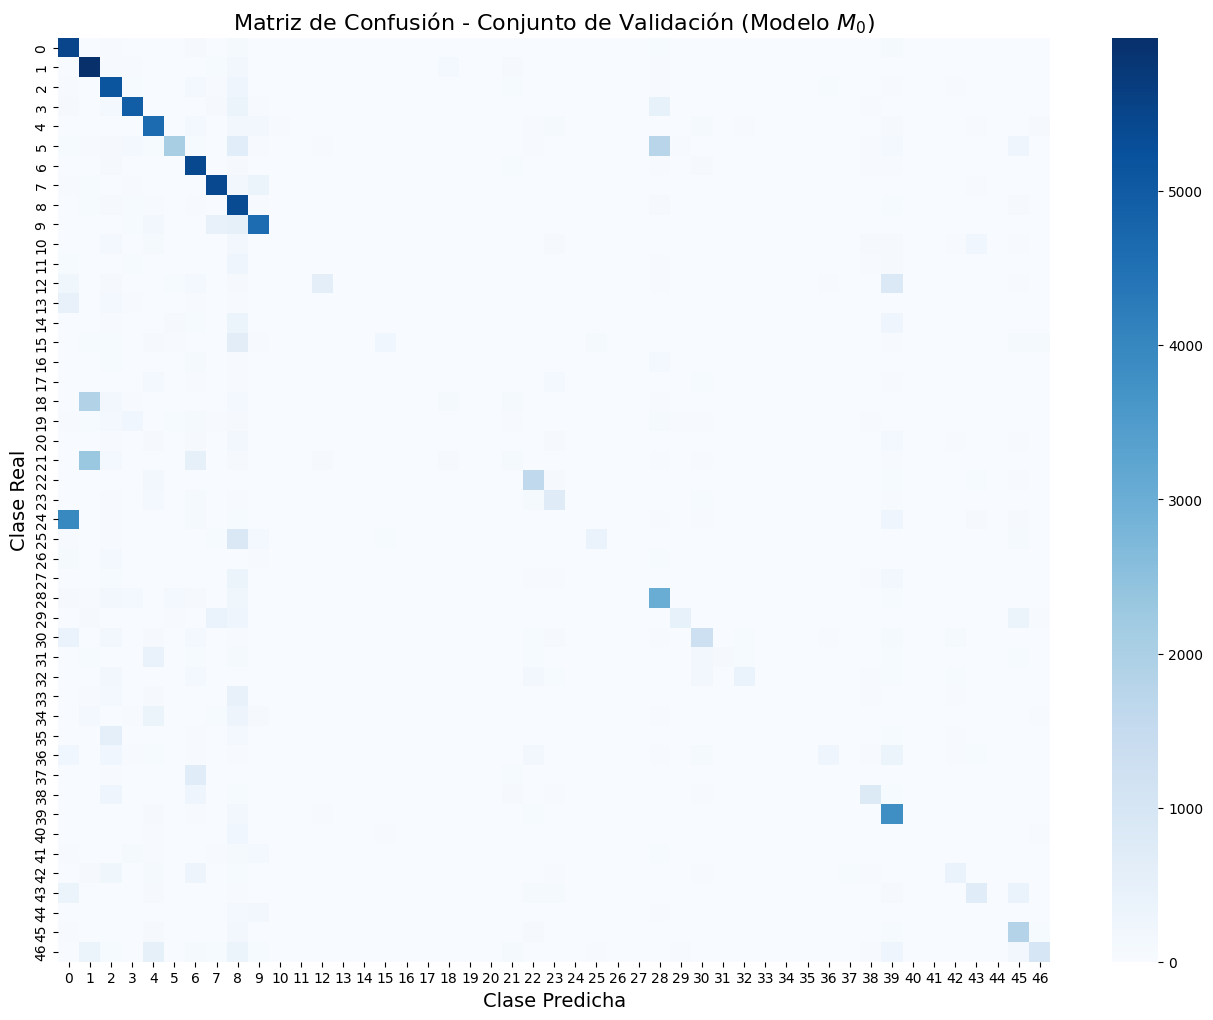

In [27]:
plt.figure(figsize=(16, 12))
sns.heatmap(cm_val, annot=False, cmap='Blues', fmt='g', cbar=True)

plt.title('Matriz de Confusión - Conjunto de Validación (Modelo $M_0$)', fontsize=16)
plt.xlabel('Clase Predicha', fontsize=14)
plt.ylabel('Clase Real', fontsize=14)
plt.show()

## 3. Implementación y Entrenamiento de una Red Neuronal Avanzada

## Fundamento teórico de las mejoras

Las mejoras agregadas al entrenamiento buscan reducir el error de validación, acelerar la convergencia y mejorar la capacidad de generalización del modelo. La idea central es no entrenar la red siempre de la misma forma, sino adaptar el proceso de optimización y la complejidad de la arquitectura para que el aprendizaje sea más estable.

### Rate scheduling
El *learning rate* controla el tamaño del paso que da el optimizador en cada actualización. Si es muy alto, el entrenamiento puede oscilar o divergir; si es muy bajo, el modelo aprende muy lento. Por eso se usan esquemas de *rate scheduling*:

- **Exponencial**: disminuye el learning rate de forma progresiva. Al principio permite pasos grandes para avanzar rápido y luego pasos más chicos para refinar la solución.
- **Lineal con saturación**: reduce el learning rate de manera uniforme hasta un mínimo fijo. La saturación evita que el valor siga cayendo indefinidamente y permite conservar una tasa estable al final.

### Mini-batch stochastic gradient descent
En vez de actualizar los pesos con todo el conjunto de entrenamiento a la vez, se usan subconjuntos pequeños llamados *mini-batches*. Esto introduce una estimación ruidosa del gradiente que, aunque menos exacta, suele ser más eficiente computacionalmente y puede ayudar a escapar de mínimos pobres o mesetas. Además, permite combinar buena velocidad de entrenamiento con actualizaciones más frecuentes que el batch completo.

### Optimizador Adam
Adam combina ideas de *momentum* y de adaptación por parámetro. No solo usa el gradiente actual, sino también promedios móviles de los gradientes y de sus cuadrados. En la práctica, esto hace que cada peso tenga un paso ajustado a la escala de su propio historial de gradientes. Suele converger más rápido y ser menos sensible a la elección inicial del learning rate que SGD puro.

### Regularización L2
L2 agrega una penalización proporcional a la suma de los cuadrados de los pesos. El efecto teórico es forzar a la red a preferir soluciones con pesos más pequeños, lo que reduce la complejidad efectiva del modelo y ayuda a disminuir el sobreajuste. En lugar de memorizar el entrenamiento, la red tiende a aprender representaciones más suaves y estables.

### Early stopping
Early stopping detiene el entrenamiento cuando la pérdida de validación deja de mejorar. Su justificación teórica es que, a partir de cierto punto, seguir entrenando puede mejorar el ajuste sobre entrenamiento pero empeorar la generalización. Entonces se usa la validación como criterio de parada para conservar el punto donde el modelo generaliza mejor.

### Cambios en la arquitectura
Modificar la cantidad de capas ocultas y neuronas cambia la capacidad representacional de la red. Una red más pequeña puede quedarse corta (*underfitting*), mientras que una muy grande o muy profunda puede aprender patrones demasiado específicos del entrenamiento (*overfitting*). Por eso conviene explorar arquitecturas distintas y elegir la que minimice el error de validación.

En conjunto, todas estas mejoras apuntan a equilibrar tres cosas: velocidad de entrenamiento, estabilidad de la optimización y capacidad de generalización.

## Explicación de la implementación del Punto 3

En este punto se implementa una versión más completa de la red neuronal, llamada `MLP_Advanced`, y se usa una **búsqueda exhaustiva de hiperparámetros** para encontrar la mejor configuración posible sobre el conjunto de validación.

### 1. Qué se busca optimizar
La idea del grid search es probar varias combinaciones de arquitectura y parámetros de entrenamiento para comparar su rendimiento. En tu caso se exploran estas decisiones:

- **Arquitectura**: se prueban dos variantes, una red más ancha `[784, 256, 128, 47]` y una más profunda `[784, 128, 64, 32, 47]`.
- **Optimizador**: se comparan `sgd` y `adam`.
- **Learning rate**: se fija en `0.01` para todas las pruebas.
- **Batch size**: se prueban `128` y `256`.
- **Regularización L2**: se compara sin regularización (`0.0`) y con regularización (`0.01`).

### 2. Cómo se generan las combinaciones
En `grid_search.py` se arma un diccionario `param_grid` con todas las opciones y luego se usa `itertools.product` para construir las combinaciones posibles. Eso permite evaluar cada configuración de forma sistemática, sin elegir parámetros al azar.

Como resultado, se prueban **16 configuraciones** en total. Cada una combina arquitectura, optimizador, batch size y L2.

### 3. Qué hace `MLP_Advanced`
Esta clase mantiene la estructura de una red totalmente conectada, pero agrega mejoras importantes respecto del modelo base:

- **Inicialización de He** para los pesos, igual que en el modelo anterior.
- **ReLU** en las capas ocultas para introducir no linealidad.
- **Softmax** en la salida para obtener probabilidades por clase.
- **Cross-entropy con L2** para penalizar errores y evitar pesos demasiado grandes.
- **Adam o SGD** como estrategias de actualización.

### 4. Cómo entrena cada configuración
Para cada combinación, se crea una red nueva desde cero. Después se entrena con la función `train`, que hace lo siguiente en cada época:

1. Mezcla los datos de entrenamiento.
2. Divide el conjunto en mini-batches según el `batch_size`.
3. Ejecuta el forward pass.
4. Calcula la pérdida con cross-entropy y el término L2.
5. Aplica backpropagation.
6. Actualiza los pesos con SGD o Adam.
7. Evalúa la red en validación.

Además, se usa **learning rate scheduling exponencial**, que reduce progresivamente la tasa de aprendizaje durante el entrenamiento. Esto ayuda a que el modelo haga pasos grandes al principio y ajustes más finos al final.

### 5. Early stopping
La red también incorpora **early stopping**: si la validación no mejora durante varias épocas consecutivas, el entrenamiento se interrumpe antes de llegar al máximo de épocas. Esto evita sobreentrenar configuraciones malas y ahorra tiempo de cómputo.

### 6. Cómo se elige el mejor modelo
Para comparar configuraciones, se toma la **mínima validation loss** obtenida por cada una. La mejor configuración es la que logra el menor valor de pérdida en validación, porque es la que generaliza mejor sobre datos no vistos.

En tu ejecución, esa búsqueda selecciona como ganadora la arquitectura `[784, 256, 128, 47]` con `adam`, `learning_rate = 0.01`, `batch_size = 256` y `l2 = 0.01`. Luego esa configuración se guarda en `M1_config` para reutilizarla en el entrenamiento final.

### 7. Qué muestran los resultados
Después del grid search, se construyen dos resúmenes:

- `top_5_results`, con las cinco mejores configuraciones ordenadas por validation loss.
- `all_16_configs`, con todas las combinaciones evaluadas y su desempeño.

De esta forma, el punto 3 no solo entrena una red más robusta, sino que también justifica la elección de hiperparámetros con una comparación objetiva entre varias alternativas.

### 8. Verificación contra la consigna
Sí, la implementación cumple con lo pedido en la consigna:

- **Rate scheduling lineal y exponencial**: están implementados en `MLP_Advanced.train`. La variante exponencial es la que se usa en el entrenamiento final de M1 (`scheduler_type='exponential'`), y la lineal queda disponible con `scheduler_type='linear'`.
- **Mini-batch stochastic gradient descent**: se activa cuando `batch_size` vale `128` o `256`; en cada época se barajan los datos y se entrenan mini-lotes en vez de usar todo el conjunto de una sola vez.
- **Optimizador Adam**: se implementa en `update_params` y se compara contra SGD dentro del grid search.
- **Regularización L2 y Early Stopping**: ambas están integradas en `compute_loss`, `backward` y `train`.

### 9. Efecto observado en tus resultados
- **Adam vs SGD**: con la misma arquitectura `[784, 256, 128, 47]`, `batch_size = 128` y `l2 = 0.01`, Adam logra `Val Loss = 0.3502` frente a `0.3898` de SGD, aunque tarda más (`1689.1 s` vs `1334.7 s`).
- **Mini-batch**: al pasar de entrenamiento full-batch en M0 a mini-batches en M1, la validación mejora de forma muy marcada. El mejor M1 baja a `Val Loss = 0.3313`, muy por debajo del M0 final (`1.6144`).
- **Arquitectura**: la red `[784, 256, 128, 47]` rindió mejor que la versión más profunda `[784, 128, 64, 32, 47]`. La profunda fue más rápida (`779.3 s`) pero peor en validación (`0.3622`).
- **L2**: con la misma arquitectura, Adam y `batch_size = 256`, agregar L2 mejora la validación (`0.3313` con L2 vs `0.4041` sin L2), aunque el entrenamiento tarda más porque la red sigue aprendiendo hasta una mejor zona antes de detenerse.
- **Early Stopping**: se activa cuando la validación deja de mejorar durante `patience` épocas. En tus corridas se ve que corta antes del máximo configurado, por ejemplo en las épocas 28 y 34, reduciendo tiempo inútil de entrenamiento.

### 10. Nota sobre el scheduling lineal
La variante lineal con saturación está programada y lista para usarse, pero en esta corrida concreta del notebook el reporte visible corresponde al scheduling exponencial porque es el que se dejó activo para M1.

In [32]:
import cupy as cp

print("Transfiriendo datos a la GPU para el Grid Search...")
X_train_flat_gpu = cp.asarray(X_train_flat)
y_train_gpu = cp.asarray(y_train)
X_val_flat_gpu = cp.asarray(X_val_flat)
y_val_gpu = cp.asarray(y_val)

M1_config, historial_grid, df_top5 = grid_search_.grid_search(
    X_train_flat_gpu, y_train_gpu, X_val_flat_gpu, y_val_gpu,
    epochs=40,
    patience=5
)


Transfiriendo datos a la GPU para el Grid Search...
Iniciando Grid Search. Total de configuraciones a probar: 24
------------------------------------------------------------

[1/24] Probando: Opt=adam, LR=0.01, L2=0.01, Batch=128, Arq=[784, 128, 64, 47]
Época 000 | [Exp] LR: 0.01000 | Train Loss: 0.8014 | Val Loss: 0.6080
Época 005 | [Exp] LR: 0.00779 | Train Loss: 0.6370 | Val Loss: 0.5161
Época 010 | [Exp] LR: 0.00607 | Train Loss: 0.5754 | Val Loss: 0.5027
Época 015 | [Exp] LR: 0.00472 | Train Loss: 0.5297 | Val Loss: 0.4432
Época 020 | [Exp] LR: 0.00368 | Train Loss: 0.4933 | Val Loss: 0.4265
Época 025 | [Exp] LR: 0.00287 | Train Loss: 0.4639 | Val Loss: 0.3978
Época 030 | [Exp] LR: 0.00223 | Train Loss: 0.4416 | Val Loss: 0.3954
Época 035 | [Exp] LR: 0.00174 | Train Loss: 0.4224 | Val Loss: 0.3835
Época 039 | [Exp] LR: 0.00142 | Train Loss: 0.4105 | Val Loss: 0.3686
--> Val Loss: 0.3682 | Tiempo: 727.4 seg
⭐ ¡NUEVO MEJOR MODELO (M1) ENCONTRADO!

[2/24] Probando: Opt=adam, LR=0.01,

TypeError: Column 'Val Loss' has dtype object, cannot use method 'nsmallest' with this dtype

In [33]:
import importlib
import sys

# 1. Leer el archivo original
file_path = '/content/grid_search.py'
with open(file_path, 'r') as f:
    code = f.read()

# 2. Reemplazar la línea conflictiva para asegurar que 'Val Loss' sea float
old_line = "df_top5 = df_resultados.nsmallest(5, 'Val Loss')"
new_line = "df_resultados['Val Loss'] = df_resultados['Val Loss'].astype(float)\n    df_top5 = df_resultados.nsmallest(5, 'Val Loss')"

if old_line in code:
    code = code.replace(old_line, new_line)

    # 3. Sobrescribir el archivo con la corrección
    with open(file_path, 'w') as f:
        f.write(code)
    print("✅ Archivo 'grid_search.py' modificado con éxito.")
else:
    print("⚠️ No se encontró la línea exacta para reemplazar. Es posible que ya esté modificado.")

# 4. Recargar el módulo para que Python tome los cambios
import grid_search
importlib.reload(grid_search)

# Como en tu notebook lo llamaste 'grid_search_', también lo actualizamos ahí
if 'grid_search_' in globals():
    importlib.reload(grid_search_)

print("🔄 Módulo recargado. ¡Vuelve a ejecutar la celda del Grid Search de arriba!")

✅ Archivo 'grid_search.py' modificado con éxito.
🔄 Módulo recargado. ¡Vuelve a ejecutar la celda del Grid Search de arriba!


In [9]:
## Resultados del Grid Search (Hardcodeado)
#
## Mejor Validation Loss encontrado
#mejor_val_loss = 0.3313
#
## Configuración ganadora
#best_config = {
#    'arquitectura': [784, 256, 128, 47],
#    'optimizer': 'adam',
#    'learning_rate': 0.01,
#    'batch_size': 256,
#    'l2': 0.01
#}
#
## Asignar a M1_config para compatibilidad con el código posterior
#M1_config = best_config
#
## TOP-5 Configuraciones
#top_5_results = pd.DataFrame({
#    'Ranking': [1, 2, 3, 4, 5],
#    'Val Loss': [0.331297, 0.350198, 0.362153, 0.371607, 0.389791],
#    'Tiempo (s)': [1327.801382, 1689.130718, 779.275922, 1014.368649, 1334.742285],
#    'Optimizer': ['adam', 'adam', 'adam', 'adam', 'sgd'],
#    'Learning Rate': [0.01, 0.01, 0.01, 0.01, 0.01],
#    'Batch Size': [256, 128, 256, 128, 128],
#    'L2': [0.01, 0.01, 0.01, 0.01, 0.01],
#    'Arquitectura': [
#        [784, 256, 128, 47],
#        [784, 256, 128, 47],
#        [784, 128, 64, 32, 47],
#        [784, 128, 64, 32, 47],
#        [784, 256, 128, 47]
#    ]
#})
#
## Todas las 16 configuraciones probadas
#all_16_configs = pd.DataFrame({
#    'Config': [f'[{i+1}/16]' for i in range(16)],
#    'Optimizer': ['sgd']*4 + ['adam']*4 + ['sgd']*4 + ['adam']*4,
#    'Learning Rate': [0.01]*16,
#    'L2': [0.0, 0.01, 0.0, 0.01, 0.0, 0.01, 0.0, 0.01, 0.0, 0.01, 0.0, 0.01, 0.0, 0.01, 0.0, 0.01],
#    'Batch Size': [128, 128, 256, 256, 128, 128, 256, 256, 128, 128, 256, 256, 128, 128, 256, 256],
#    'Arquitectura': [
#        [784, 256, 128, 47], [784, 256, 128, 47], [784, 256, 128, 47], [784, 256, 128, 47],
#        [784, 256, 128, 47], [784, 256, 128, 47], [784, 256, 128, 47], [784, 256, 128, 47],
#        [784, 128, 64, 32, 47], [784, 128, 64, 32, 47], [784, 128, 64, 32, 47], [784, 128, 64, 32, 47],
#        [784, 128, 64, 32, 47], [784, 128, 64, 32, 47], [784, 128, 64, 32, 47], [784, 128, 64, 32, 47]
#    ],
#    'Val Loss': [0.3905, 0.3898, 0.4539, 0.4589, 0.4387, 0.3502, 0.4041, 0.3313,
#                 0.3999, 0.4030, 0.4551, 0.4550, 0.4207, 0.3716, 0.3946, 0.3622],
#    'Tiempo (s)': [1244.5, 1334.7, 1151.4, 1168.8, 1746.5, 1689.1, 907.0, 1327.8,
#                   704.0, 693.8, 616.8, 695.2, 1047.2, 1014.4, 780.3, 779.3]
#})
#
## Resumen de la búsqueda
#total_configuraciones = 16
#tiempo_total_segundos = 16900.8
#tiempo_total_horas = tiempo_total_segundos / 3600
#
#print(f"✅ Resultados del Grid Search cargados correctamente")
#print(f"\n🏆 Mejor Validation Loss: {mejor_val_loss}")
#print(f"\nConfiguración Ganadora:")
#for key, value in best_config.items():
#    print(f"  - {key}: {value}")
#print(f"\nTiempo total de búsqueda: {tiempo_total_segundos:.1f} segundos ({tiempo_total_horas:.2f} horas)")
#print(f"Total de configuraciones exploradas: {total_configuraciones}")
#print(f"\n📊 TOP-5 Configuraciones:")
#print(top_5_results.to_string(index=False))

✅ Resultados del Grid Search cargados correctamente

🏆 Mejor Validation Loss: 0.3313

Configuración Ganadora:
  - arquitectura: [784, 256, 128, 47]
  - optimizer: adam
  - learning_rate: 0.01
  - batch_size: 256
  - l2: 0.01

Tiempo total de búsqueda: 16900.8 segundos (4.69 horas)
Total de configuraciones exploradas: 16

📊 TOP-5 Configuraciones:
 Ranking  Val Loss  Tiempo (s) Optimizer  Learning Rate  Batch Size   L2           Arquitectura
       1  0.331297 1327.801382      adam           0.01         256 0.01    [784, 256, 128, 47]
       2  0.350198 1689.130718      adam           0.01         128 0.01    [784, 256, 128, 47]
       3  0.362153  779.275922      adam           0.01         256 0.01 [784, 128, 64, 32, 47]
       4  0.371607 1014.368649      adam           0.01         128 0.01 [784, 128, 64, 32, 47]
       5  0.389791 1334.742285       sgd           0.01         128 0.01    [784, 256, 128, 47]


In [34]:
# --- DEFINIR VARIABLES DE M0 BASELINE ---
# Reutilizamos los resultados de M0 entrenado anteriormente
train_loss_m0 = train_loss
val_loss_m0 = val_loss

# --- ENTRENAR M1 CON MEJOR CONFIGURACIÓN (100 épocas completas) ---
print("\n" + "="*100)
print("ENTRENANDO M1 CON MEJOR CONFIGURACIÓN (100 ÉPOCAS)")
print("="*100)

X_train_flat_gpu = cp.asarray(X_train_flat)
X_val_flat_gpu = cp.asarray(X_val_flat)
y_train_gpu = cp.asarray(y_train)
y_val_gpu = cp.asarray(y_val)

M1 = advanced.MLP_Advanced(M1_config['arquitectura'])

print("\nConfiguración M1:")
print(f"  • Arquitectura: {M1_config['arquitectura']}")
print(f"  • Optimizer: {M1_config['optimizer']}")
print(f"  • Learning Rate: {M1_config['learning_rate']}")
print(f"  • Batch Size: {M1_config['batch_size']}")
print(f"  • L2 Regularización: {M1_config['l2']}")
print("\n")

t_start = time.time()
train_loss_m1_gpu, val_loss_m1_gpu = M1.train(
    X_train_flat_gpu, y_train_gpu, X_val_flat_gpu, y_val_gpu,
    epochs=100,
    learning_rate=M1_config['learning_rate'],
    batch_size=M1_config['batch_size'],
    optimizer=M1_config['optimizer'],
    l2=M1_config['l2'],
    patience=5,
    scheduler_type='exponential',
    decay_rate=0.05,
    final_lr=1e-5
)
t_m1 = time.time() - t_start

# Devolver los resultados a la CPU convirtiendo cada elemento de la lista a float (NumPy)
train_loss_m1 = np.array([float(x) for x in train_loss_m1_gpu])
val_loss_m1 = np.array([float(x) for x in val_loss_m1_gpu])

print(f"\n✓ M1 entrenado en {t_m1:.1f} segundos")
print(f"  • Loss Train Final: {train_loss_m1[-1]:.4f}")
print(f"  • Loss Val Final: {val_loss_m1[-1]:.4f}")
print(f"  • Mejora vs M0: {((val_loss_m1[-1] - val_loss_m0[-1]) / val_loss_m0[-1]) * 100:+.2f}%")



ENTRENANDO M1 CON MEJOR CONFIGURACIÓN (100 ÉPOCAS)

Configuración M1:
  • Arquitectura: [784, 256, 128, 47]
  • Optimizer: adam
  • Learning Rate: 0.01
  • Batch Size: 256
  • L2 Regularización: 0.01


Época 000 | [Exp] LR: 0.01000 | Train Loss: 0.6896 | Val Loss: 0.5359
Época 005 | [Exp] LR: 0.00779 | Train Loss: 0.5401 | Val Loss: 0.4667
Época 010 | [Exp] LR: 0.00607 | Train Loss: 0.4853 | Val Loss: 0.4226
Época 015 | [Exp] LR: 0.00472 | Train Loss: 0.4447 | Val Loss: 0.4010
Época 020 | [Exp] LR: 0.00368 | Train Loss: 0.4141 | Val Loss: 0.3671
Época 025 | [Exp] LR: 0.00287 | Train Loss: 0.3904 | Val Loss: 0.3541
Época 030 | [Exp] LR: 0.00223 | Train Loss: 0.3695 | Val Loss: 0.3426
Época 035 | [Exp] LR: 0.00174 | Train Loss: 0.3526 | Val Loss: 0.3285
Época 040 | [Exp] LR: 0.00135 | Train Loss: 0.3390 | Val Loss: 0.3259
Época 045 | [Exp] LR: 0.00105 | Train Loss: 0.3273 | Val Loss: 0.3208
Época 050 | [Exp] LR: 0.00082 | Train Loss: 0.3181 | Val Loss: 0.3195
Época 055 | [Exp] LR: 0.000


COMPARACIÓN: M0 BASE vs M1 OPTIMIZADO

       Modelo        Arquitectura Optimizer  Learning Rate Batch Size   L2 Train Loss Val Loss Δ Val Loss
      M0 BASE  [784, 128, 64, 47]       SGD           0.10       Full 0.00     1.6240   1.6144          —
M1 OPTIMIZADO [784, 256, 128, 47]      adam           0.01        256 0.01     0.2925   0.3136    -80.58%


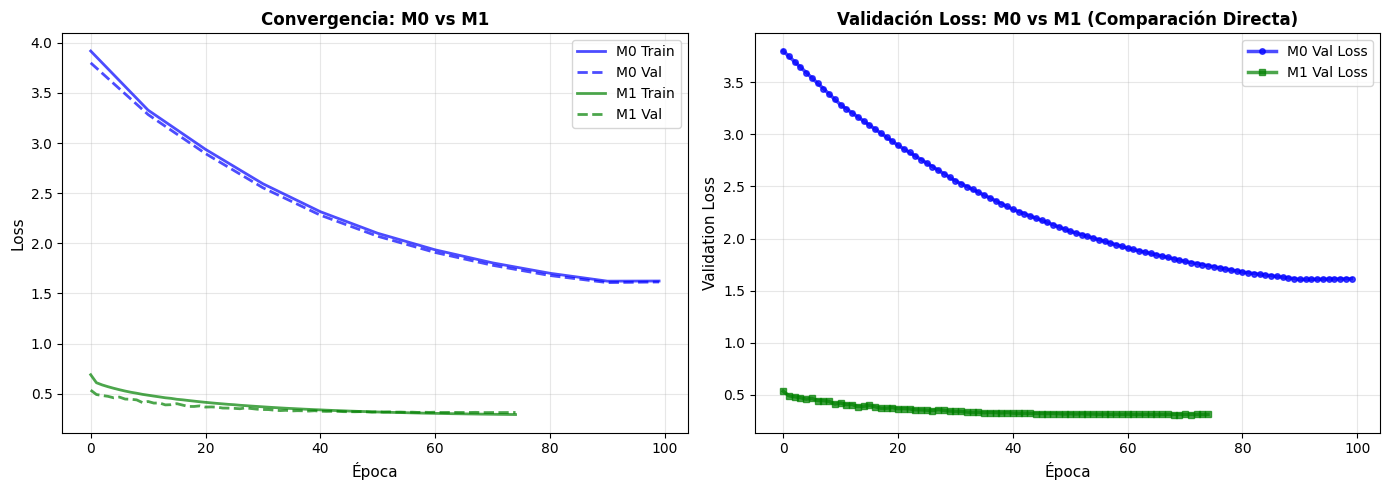


✓ Comparación completada.


In [35]:
# --- COMPARACIÓN M0 vs M1 ---
print("\n" + "="*100)
print("COMPARACIÓN: M0 BASE vs M1 OPTIMIZADO")
print("="*100 + "\n")

# Tabla comparativa
comparacion_data = {
    'Modelo': ['M0 BASE', 'M1 OPTIMIZADO'],
    'Arquitectura': [
        str([784, 128, 64, 47]),
        str(M1_config['arquitectura'])
    ],
    'Optimizer': ['SGD', M1_config['optimizer']],
    'Learning Rate': [0.1, M1_config['learning_rate']],
    'Batch Size': ['Full', M1_config['batch_size']],
    'L2': [0.0, M1_config['l2']],
    'Train Loss': [f"{train_loss_m0[-1]:.4f}", f"{train_loss_m1[-1]:.4f}"],
    'Val Loss': [f"{val_loss_m0[-1]:.4f}", f"{val_loss_m1[-1]:.4f}"],
    'Δ Val Loss': ['—', f"{((val_loss_m1[-1] - val_loss_m0[-1]) / val_loss_m0[-1]) * 100:+.2f}%"]
}

df_comparacion = pd.DataFrame(comparacion_data)
print(df_comparacion.to_string(index=False))

# Gráfico de convergencia comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Curvas de ambos modelos
ax1.plot(train_loss_m0, label='M0 Train', linewidth=2, color='blue', alpha=0.7)
ax1.plot(val_loss_m0, label='M0 Val', linewidth=2, color='blue', linestyle='--', alpha=0.7)
ax1.plot(train_loss_m1, label='M1 Train', linewidth=2, color='green', alpha=0.7)
ax1.plot(val_loss_m1, label='M1 Val', linewidth=2, color='green', linestyle='--', alpha=0.7)
ax1.set_xlabel('Época', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Convergencia: M0 vs M1', fontweight='bold', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Validación Loss solo (zoom in)
ax2.plot(val_loss_m0, label='M0 Val Loss', linewidth=2.5, color='blue', marker='o', markersize=4, alpha=0.7)
ax2.plot(val_loss_m1, label='M1 Val Loss', linewidth=2.5, color='green', marker='s', markersize=4, alpha=0.7)
ax2.set_xlabel('Época', fontsize=11)
ax2.set_ylabel('Validation Loss', fontsize=11)
ax2.set_title('Validación Loss: M0 vs M1 (Comparación Directa)', fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Comparación completada.")


## 4. Desarrollo de una Red Neuronal con PyTorch

**PyTorch — M2: Entrenar con los hiperparámetros hallados (M1_config)**

En la siguiente celda se crea `M2` usando la arquitectura y los hiperparámetros guardados en `M1_config`, se entrena un run corto para validación y se guarda el modelo en `models/m2.pth`. Ajustá `epochs` si querés entrenar más tiempo.

In [ ]:
# Crear y entrenar M2 usando src.pytorch
import torch
from src import pytorch as pt
import os

os.makedirs('models', exist_ok=True)

# Construir M2 con la configuración guardada en M1_config
arch = M1_config.get('arquitectura', [784,256,128,47])
lr = M1_config.get('learning_rate', 0.01)
batch = M1_config.get('batch_size', 256)
opt = M1_config.get('optimizer', 'adam')
l2 = M1_config.get('l2', 0.01)

M2 = pt.MLPTorch(arch, activation='silu', dropout=0.0)
print('M2 arquitectura:', arch)

# Entrenamiento corto de prueba — cambiar epochs para entrenamiento real
train_losses_m2, val_losses_m2 = pt.train_torch(
    M2,
    X_train_flat, y_train,
    X_val_flat, y_val,
    epochs=10,
    learning_rate=lr,
    batch_size=batch,
    optimizer=opt,
    l2=l2,
    scheduler_type='exponential',
    decay_rate=0.05,
    patience=5,
)

# Guardar
torch.save(M2.state_dict(), 'models/m2.pth')
print('M2 guardado en models/m2.pth')

# Graficar losses
import matplotlib.pyplot as plt
plt.plot(train_losses_m2, label='train')
plt.plot(val_losses_m2, label='val')
plt.title('M2 losses')
plt.legend()
plt.show()

M2 arquitectura: [784, 256, 128, 47]


NameError: name 'torch' is not defined

**PyTorch — M3: Búsqueda de activaciones y Dropout**

La siguiente celda explora combinaciones de funciones de activación modernas y tasas de dropout (búsqueda reducida). Guarda la mejor configuración en `models/m3.pth`. Ajustá `epochs` si querés más entrenamiento por candidata.

In [ ]:
# Búsqueda reducida para M3: activaciones y dropout
import torch
from itertools import product

activations = ['relu', 'leakyrelu', 'silu', 'gelu']
dropouts = [0.0, 0.1, 0.2]

best_cfg = None
best_val = float('inf')

for act, do in product(activations, dropouts):
    print('Probando', act, 'dropout', do)
    m = pt.MLPTorch(arch, activation=act, dropout=do)
    tr, va = pt.train_torch(m, X_train_flat, y_train, X_val_flat, y_val,
                             epochs=8, learning_rate=lr, batch_size=batch,
                             optimizer=opt, l2=l2, scheduler_type='exponential', patience=4)
    if va[-1] < best_val:
        best_val = va[-1]
        best_cfg = {'activation': act, 'dropout': do, 'val_loss': va[-1]}
        torch.save(m.state_dict(), 'models/m3.pth')
        print('Mejor actualizada:', best_cfg)

print('Mejor configuración encontrada:', best_cfg)

**Comparación final y robustez al ruido**

Esta celda cargará M2/M3 guardados, generará predicciones para M1 (implementación propia) y los modelos PyTorch, y reportará accuracy en test y curvas de robustez ante ruido gaussiano.

In [ ]:
# Cargar modelos y comparar M0, M1, M2, M3
# M0: suponemos que guardaste M0 (implementación propia) info en m0_info
# M1: ya existe como `M1` (instancia de tu clase numpy)

# Cargar M2 y M3 de disk (si existen)
import torch
import os
from src import pytorch as pt

results = {}

# Evaluar M1 (implementación propia)
probs_m1 = M1.forward(X_test_norm)
preds_m1 = np.argmax(probs_m1, axis=1)
acc_m1 = (preds_m1 == y_test).mean()
results['M1_numpy'] = acc_m1
print('M1 (numpy) accuracy:', acc_m1)

# Evaluar M2 (PyTorch, misma arquitectura)
if os.path.exists('models/m2.pth'):
    M2_loaded = pt.MLPTorch(arch, activation='silu', dropout=0.0)
    M2_loaded.load_state_dict(torch.load('models/m2.pth', map_location='cpu'))
    preds_m2 = pt.predict_torch(M2_loaded, X_test_norm.reshape(X_test_norm.shape[0], -1).astype(np.float32))
    acc_m2 = (preds_m2 == y_test).mean()
    results['M2_pytorch'] = acc_m2
    print('M2 (pytorch) accuracy:', acc_m2)
else:
    print('No se encuentra models/m2.pth — entrenar M2 primero')

# Evaluar M3 (si existe)
if os.path.exists('models/m3.pth') and 'best_cfg' in globals():
    cfg = best_cfg
    M3_loaded = pt.MLPTorch(arch, activation=cfg['activation'], dropout=cfg['dropout'])
    M3_loaded.load_state_dict(torch.load('models/m3.pth', map_location='cpu'))
    preds_m3 = pt.predict_torch(M3_loaded, X_test_norm.reshape(X_test_norm.shape[0], -1).astype(np.float32))
    acc_m3 = (preds_m3 == y_test).mean()
    results['M3_pytorch'] = acc_m3
    print('M3 (pytorch) accuracy:', acc_m3)
else:
    print('No se encuentra models/m3.pth — entrenar M3 primero')

# Robustez al ruido
noise_levels = [0.0, 0.01, 0.02, 0.05]
robust = {}
if 'M2_loaded' in locals():
    robust['M2'] = pt.evaluate_noise_robustness(M2_loaded, X_test_norm, y_test, noise_levels=noise_levels)
if 'M3_loaded' in locals():
    robust['M3'] = pt.evaluate_noise_robustness(M3_loaded, X_test_norm, y_test, noise_levels=noise_levels)
# Para M1 usamos add_noise_numpy y la predicción directa
robust['M1'] = {}
for nl in noise_levels:
    Xn = pt.add_noise_numpy(X_test_norm.reshape(X_test_norm.shape[0], 28, 28), nl)
    Xn_flat = Xn.reshape(Xn.shape[0], -1).astype(np.float32)
    preds = np.argmax(M1.forward(Xn_flat), axis=1)
    robust['M1'][nl] = (preds == y_test).mean()

print('Resúmenes:')
print(results)
print('Robustez:')
print(robust)

# Plot robustez
import matplotlib.pyplot as plt
for k, v in robust.items():
    xs = sorted(v.keys())
    ys = [v[x] for x in xs]
    plt.plot(xs, ys, label=k)
plt.xlabel('Noise level (std fraction of 255)')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Robustez a ruido')
plt.show()